In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import json
import tempfile
from pathlib import Path

import modal
import numpy as np
from datasets import load_dataset
from huggingface_hub import HfApi, hf_hub_download
from PIL import Image, ImageDraw
from scipy.ndimage import center_of_mass

## Config

In [15]:
HF_REPO = "eturok-weizmann/laser-vibrations"

# SAM3 crop fractions — must match what was used for existing samples
LEFT, RIGHT, UP, DOWN = 0.15, 0.67, 0.08, 0.7

# Only load the columns we actually need — avoids decoding images/video/audio
NEEDED_COLS = {"sample_id", "n_objects", "speakers", "manifest"}

## Modal SAM3 setup

In [16]:
app = modal.App("resegment")

modal_image = (
    modal.Image.from_registry("nvidia/cuda:12.8.0-devel-ubuntu22.04", add_python="3.12")
    .entrypoint([])
    .apt_install("git")
    .uv_sync(uv_project_dir="../")
)


@app.cls(gpu="A10G", image=modal_image, secrets=[modal.Secret.from_name("huggingface")])
class Segmenter:
    @modal.enter()
    def load_model(self):
        from sam3.model_builder import build_sam3_image_model
        from sam3.model.sam3_image_processor import Sam3Processor
        self.model = build_sam3_image_model()
        self.processor = Sam3Processor(self.model)
        self.processor.set_confidence_threshold(0.0)

    @modal.method()
    def segment(self, image_arr: np.ndarray, prompt: str, top_k: int = 1):
        """
        Returns:
            masks:          list of top_k boolean (H, W) arrays
            aggregate_mask: boolean (H, W) — union of all top_k masks
            overlay:        float32 RGBA (H, W, 4) of the aggregate mask
        """
        import torch
        with torch.autocast("cuda", dtype=torch.bfloat16):
            state = self.processor.set_image(Image.fromarray(image_arr))
            out = self.processor.set_text_prompt(state=state, prompt=prompt)

        n = len(out["scores"])
        k = min(top_k, n)
        if n > 0:
            idx = out["scores"].topk(k).indices
            out["masks"]  = out["masks"][idx]   # (k, num_multimask, H, W)
            out["scores"] = out["scores"][idx]

        print(f"detections: {n},  keeping top_{k}")
        print(f"scores:     {out['scores'].tolist()}")

        # out["masks"][i, 0] is (H, W) — already 2D, no .any() needed
        masks = [out["masks"][i, 0].cpu().numpy().astype(bool) for i in range(k)]

        H, W = image_arr.shape[:2]
        aggregate_mask = np.zeros((H, W), dtype=bool)
        for m in masks:
            aggregate_mask |= m

        overlay = np.zeros((H, W, 4), dtype=np.float32)
        overlay[aggregate_mask] = (0.0, 0.8, 0.2, 0.5)

        return masks, aggregate_mask, overlay

## Helpers

In [74]:
import matplotlib.pyplot as plt
import math

ASSETS_DIR   = Path("../assets")
SPEAKER_DIR  = ASSETS_DIR / "speakers"
SPEAKER_FILES = ("1000", "0100", "0010", "0001")
PADDED_BG    = (232, 232, 232)
MASK_COLORS  = [(255, 60, 60), (60, 100, 255), (255, 200, 0), (160, 0, 255)]
# Lighter shades of each MASK_COLORS entry for the per-mask CoM crosshairs
MASK_COM_COLORS = [(255, 180, 180), (160, 200, 255), (255, 240, 160), (220, 160, 255)]
AGG_COM_COLOR   = (255, 0, 0)


def hf_load_image(image_dir: str, filename: str) -> Image.Image:
    path = hf_hub_download(
        repo_id=HF_REPO, repo_type="dataset",
        filename=f"image/{image_dir}/{filename}",
    )
    return Image.open(path).convert("RGB")


def overlay_mask(image: Image.Image, mask: np.ndarray,
                 color=(0, 204, 51), alpha=0.45,
                 com_color=(255, 0, 0), com_radius=20) -> Image.Image:
    arr = np.array(image.convert("RGB")).astype(float)
    tint = np.zeros((*mask.shape, 3), dtype=float)
    tint[mask] = color
    blended = np.clip(arr * (1 - alpha * mask[..., None]) + tint * alpha, 0, 255).astype(np.uint8)
    result = Image.fromarray(blended)
    y_com, x_com = center_of_mass(mask.astype(float))
    r = com_radius
    draw = ImageDraw.Draw(result)
    draw.line([(x_com - r, y_com), (x_com + r, y_com)], fill=com_color, width=4)
    draw.line([(x_com, y_com - r), (x_com, y_com + r)], fill=com_color, width=4)
    return result


def plot_masks(image: Image.Image, masks: list, aggregate_mask: np.ndarray):
    """One subplot per individual mask + one aggregate, with CoM printed and shown."""
    coms = [center_of_mass(m.astype(float)) for m in masks]
    for i, (y, x) in enumerate(coms):
        print(f"  mask[{i}]: x_com={x:.1f}  y_com={y:.1f}")
    y_agg, x_agg = center_of_mass(aggregate_mask.astype(float))
    print(f"aggregate:  x_com={x_agg:.1f}  y_com={y_agg:.1f}")

    ncols = len(masks) + 1
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))
    for i, (m, (y, x)) in enumerate(zip(masks, coms)):
        axes[i].imshow(overlay_mask(image, m, color=MASK_COLORS[i % len(MASK_COLORS)]))
        axes[i].set_title(f"mask[{i}]  CoM ({x:.0f}, {y:.0f})")
        axes[i].axis("off")
    axes[-1].imshow(overlay_mask(image, aggregate_mask))
    axes[-1].set_title(f"aggregate  CoM ({x_agg:.0f}, {y_agg:.0f})")
    axes[-1].axis("off")
    plt.tight_layout()
    plt.show()


def build_multi_mask_overlay(cropped_image: Image.Image, masks) -> Image.Image:
    """Tint each mask its own color, draw per-mask CoM in lighter shade, aggregate CoM in red."""
    if isinstance(masks, np.ndarray): masks = [masks]
    arr = np.array(cropped_image.convert("RGB")).astype(float)
    alpha = 0.45
    r = 20

    for i, mask in enumerate(masks):
        color = MASK_COLORS[i % len(MASK_COLORS)]
        tint = np.zeros((*mask.shape, 3), dtype=float)
        tint[mask] = color
        arr = np.clip(arr * (1 - alpha * mask[..., None]) + tint * alpha, 0, 255)

    result = Image.fromarray(arr.astype(np.uint8))
    draw = ImageDraw.Draw(result)

    for i, mask in enumerate(masks):
        com_color = MASK_COM_COLORS[i % len(MASK_COM_COLORS)]
        y_com, x_com = center_of_mass(mask.astype(float))
        draw.line([(x_com - r, y_com), (x_com + r, y_com)], fill=com_color, width=4)
        draw.line([(x_com, y_com - r), (x_com, y_com + r)], fill=com_color, width=4)

    aggregate = np.zeros(masks[0].shape, dtype=bool)
    for m in masks:
        aggregate |= m
    y_agg, x_agg = center_of_mass(aggregate.astype(float))
    draw.line([(x_agg - r, y_agg), (x_agg + r, y_agg)], fill=AGG_COM_COLOR, width=5)
    draw.line([(x_agg, y_agg - r), (x_agg, y_agg + r)], fill=AGG_COM_COLOR, width=5)

    return result


def apply_speaker_overlay(img: Image.Image, speakers: str) -> Image.Image:
    # Matches rebuild_overhead_artifacts.py: use speaker.png for sizing AND drawing.
    # The per-speaker {key}.png files are 286x255 while speaker.png is 640x640,
    # so mixing them produces wrong canvas padding. Use speaker.png for everything.
    inner = img.convert("RGB")
    inner_width, inner_height = inner.size

    reference_icon = Image.open(SPEAKER_DIR / "speaker.png").convert("RGBA")
    base_icon_height = int(inner_height * 0.40)
    orig_w, orig_h = reference_icon.size
    base_icon_width = int(orig_w * base_icon_height / orig_h)

    padded_width  = inner_width  + base_icon_width
    padded_height = inner_height + base_icon_height
    canvas = Image.new("RGB", (padded_width, padded_height), PADDED_BG)
    canvas.paste(inner, (base_icon_width // 2, base_icon_height // 2))

    if "1" not in speakers:
        return canvas

    composite = canvas.convert("RGBA")
    for bit, key in zip(speakers, SPEAKER_FILES):
        if bit != "1":
            continue
        icon = Image.open(SPEAKER_DIR / "speaker.png").convert("RGBA")
        icon = icon.resize((base_icon_width, base_icon_height), Image.LANCZOS)
        if key == "1000":
            px, py = 0, padded_height // 2 - icon.height // 2
        elif key == "0100":
            px, py = padded_width // 3 - icon.width // 2, padded_height - icon.height
        elif key == "0010":
            px, py = 2 * padded_width // 3 - icon.width // 2, padded_height - icon.height
        elif key == "0001":
            px, py = padded_width - icon.width, padded_height // 2 - icon.height // 2
        else:
            px, py = 0, 0
        composite.alpha_composite(icon, (px, py))
    return composite.convert("RGB")


def build_segmented_overhead(cropped_image: Image.Image, masks, speakers: str) -> Image.Image:
    """Multi-color mask overlay + speaker icons. masks is a list of bool arrays."""
    return apply_speaker_overlay(build_multi_mask_overlay(cropped_image, masks), speakers)


def plot_segmented_overhead(cropped_image: Image.Image, masks, speakers: str):
    """Preview the final segmented overhead image (multi-color masks + speaker icons) inline."""
    img = build_segmented_overhead(cropped_image, masks, speakers)
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"segmented_overhead  speakers={speakers}")
    plt.tight_layout()
    plt.show()


## Load dataset — filter to n_objects >= 2

We remove the image/video/audio columns before loading to avoid downloading and decoding large media files.

## Sanity-check grid

Show all samples in `multi_ds` as a 6-column grid with the segmented overhead image and CoM in each title.
Run this **before** resegmenting to see the current state, and again **after** to verify the update.

In [18]:

def show_segmentation_grid(dataset, title="Segmentation grid"):
    n = len(dataset)
    ncols = 6
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, row in enumerate(dataset):
        manifest = json.loads(row["manifest"])
        seg_rel  = manifest["artifacts"]["segmented_overhead"]
        x_com    = manifest["segmentation"].get("x_com")
        y_com    = manifest["segmentation"].get("y_com")

        img_path = hf_hub_download(repo_id=HF_REPO, repo_type="dataset", filename=seg_rel)
        img      = Image.open(img_path).convert("RGB")

        ax = axes[i]
        ax.imshow(img)
        if x_com is not None and y_com is not None:
            ax.plot(x_com, y_com, "r+", markersize=12, markeredgewidth=2)
        com_str = f"CoM ({x_com:.0f}, {y_com:.0f})" if x_com is not None else "CoM: N/A"
        ax.set_title(f"id={row['sample_id']}\n{com_str}", fontsize=8)
        ax.axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

In [85]:
# load_dataset only fetches metadata.jsonl — no images/audio/video yet.
# remove_columns must happen before any row access so HF never decodes those columns.
ds = load_dataset(HF_REPO, split="train")
ds = ds.remove_columns([c for c in ds.column_names if c not in NEEDED_COLS])
multi_ds = ds.filter(lambda row: (row["n_objects"] or 0) >= 2)
print(f"{len(ds)} total samples → {len(multi_ds)} with n_objects >= 2")
multi_ds

metadata.jsonl: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Filter:   0%|          | 0/551 [00:00<?, ? examples/s]

551 total samples → 20 with n_objects >= 2


Dataset({
    features: ['sample_id', 'speakers', 'n_objects', 'manifest'],
    num_rows: 20
})

image/cube-006x-000y-2obj-cardboard-2026(…):   0%|          | 0.00/1.20M [00:00<?, ?B/s]

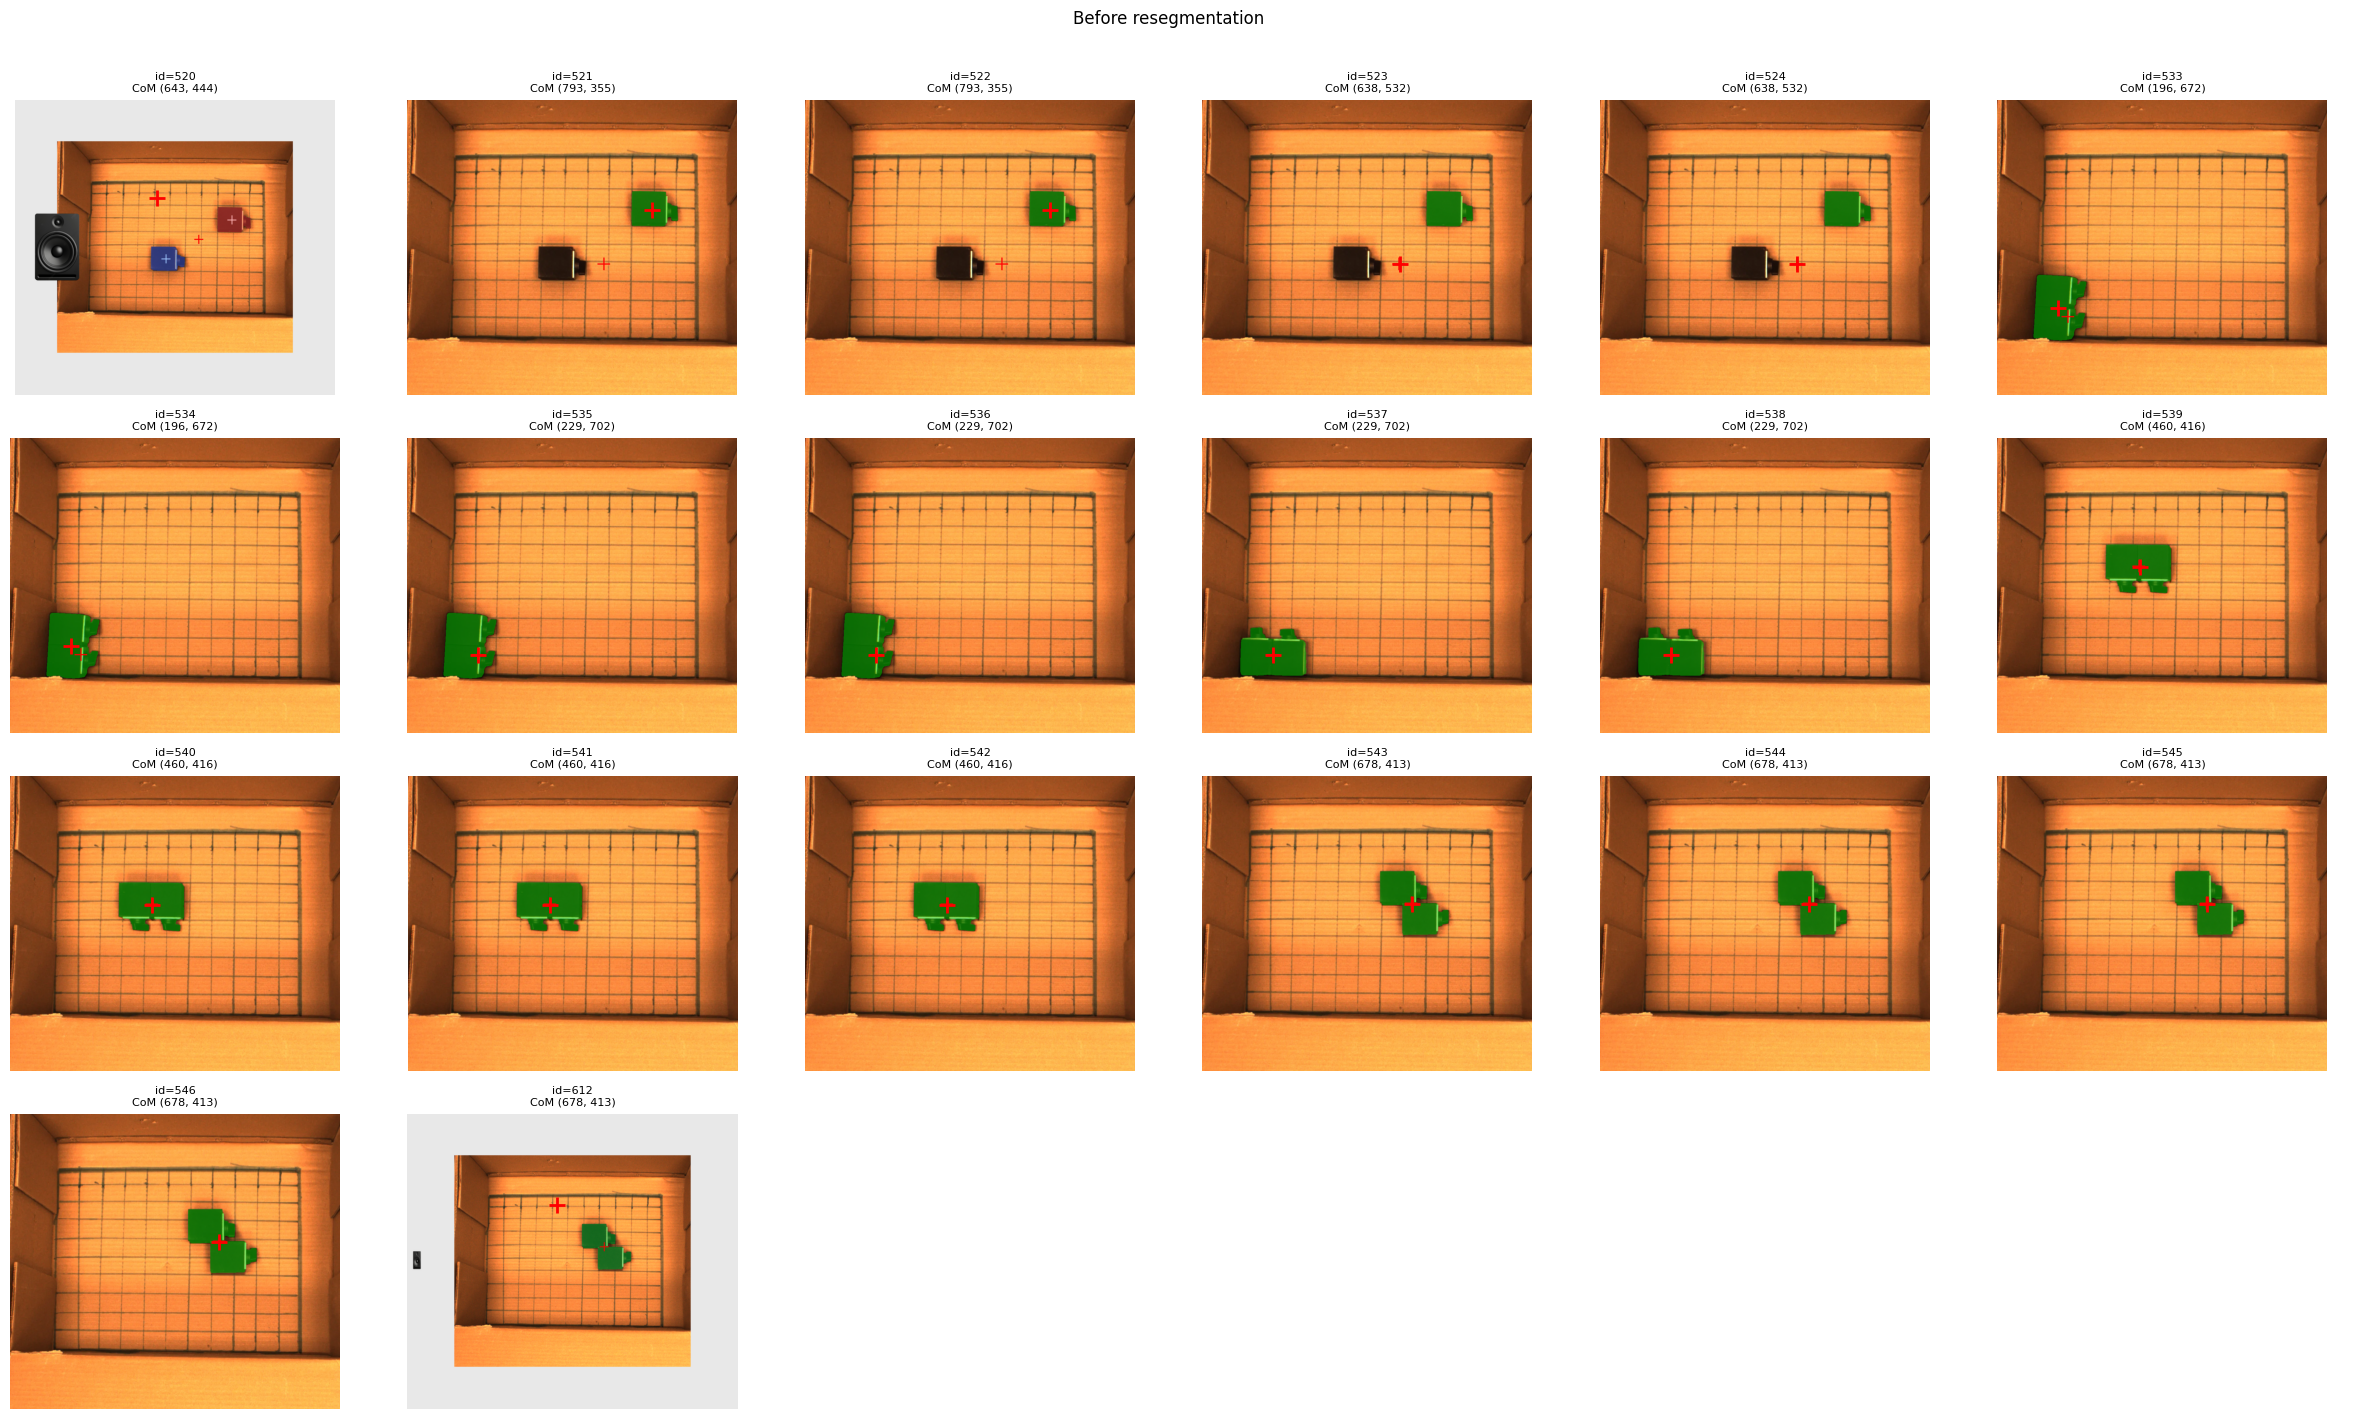

In [86]:
# Run before resegmenting
show_segmentation_grid(multi_ds, title="Before resegmentation")

## Interactive: try one sample

Set `SAMPLE_IDX` and `PROMPT`, run to preview the result before touching anything.

In [76]:
SAMPLE_IDX = 0   # index into multi_ds (not sample_id)
# PROMPT = "Two black metal cubes sitting on the floor of an open cardboard box from a bird's eye view. The cubes are staggered, placed at a zigzag, one slightly before the other."
PROMPT = "Two black metal cubes sitting on the floor of an open cardboard box from a bird's eye view"
TOP_K = 2        # number of top SAM3 detections to keep (use 2 for two-object samples)

sample_id=520  image_dir=cube-006x-000y-2obj-cardboard-2026-03-31-18-18-39  n_objects=2


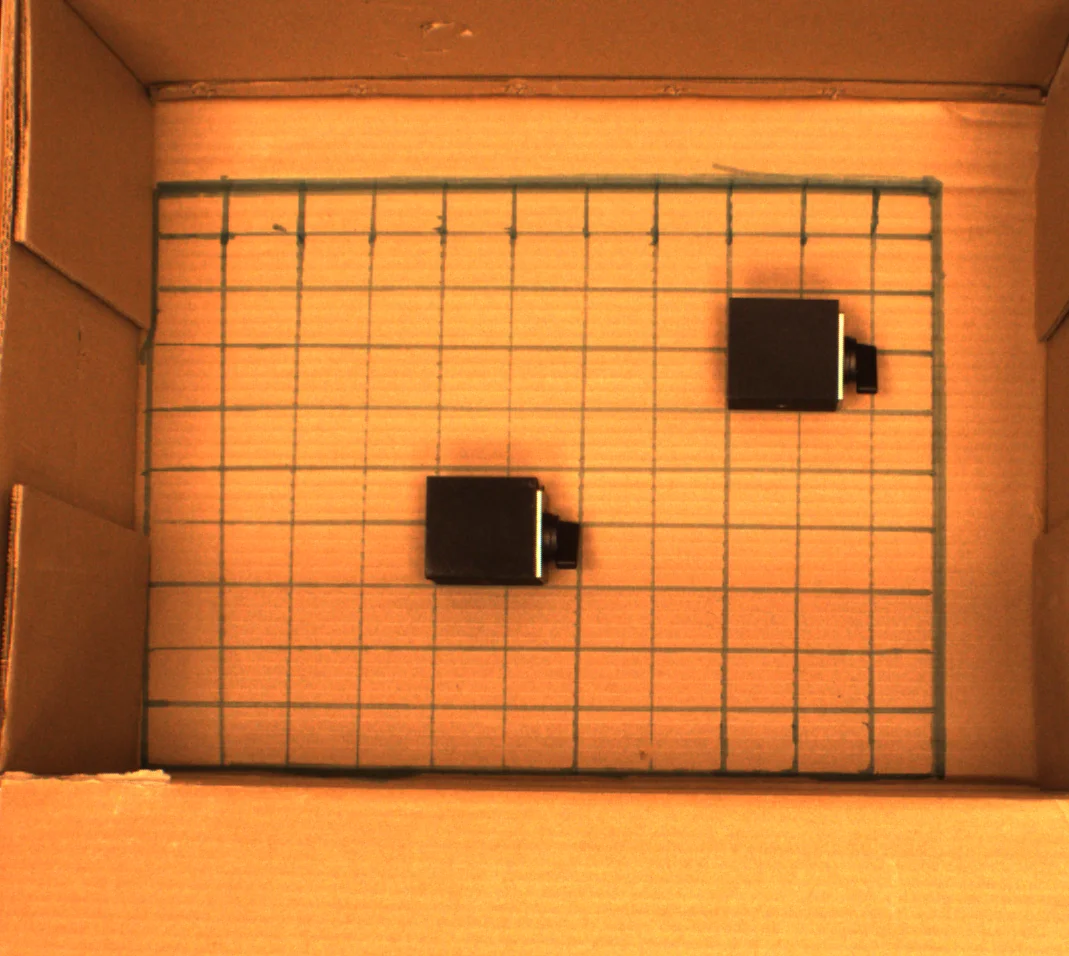

In [77]:
row = multi_ds[SAMPLE_IDX]
manifest = json.loads(row["manifest"])
image_dir = manifest["sample"]["image_dir"]
print(f"sample_id={row['sample_id']}  image_dir={image_dir}  n_objects={row['n_objects']}")

cropped_image = hf_load_image(image_dir, "cropped_overhead.png")
display(cropped_image)

In [78]:
with app.run():
    masks, aggregate_mask, overlay = Segmenter().segment.remote(np.array(cropped_image), PROMPT, top_k=TOP_K)

print(f"Individual masks: {len(masks)},  aggregate coverage: {aggregate_mask.mean()*100:.1f}%")

Individual masks: 2,  aggregate coverage: 2.8%


  mask[0]: x_com=792.9  y_com=355.5
  mask[1]: x_com=493.3  y_com=531.6
aggregate:  x_com=642.9  y_com=443.7


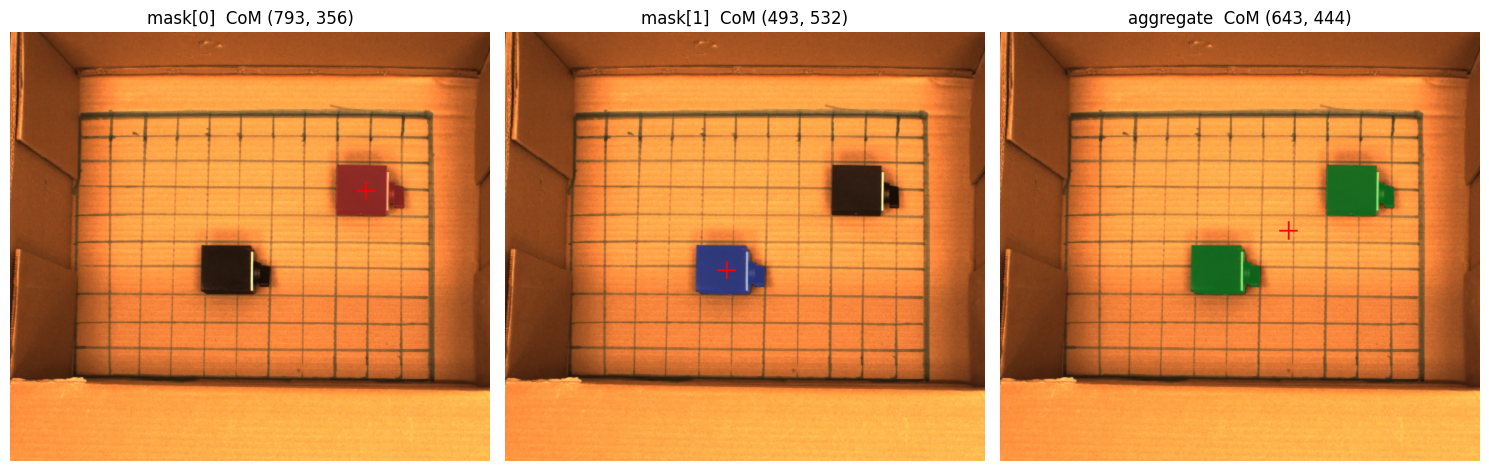

In [79]:
plot_masks(cropped_image, masks, aggregate_mask)

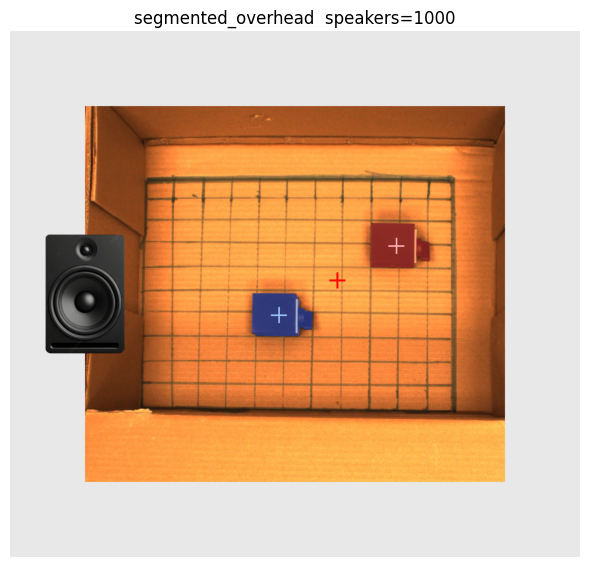

In [80]:
plot_segmented_overhead(cropped_image, masks, row['speakers'])

In [ ]:
1/0

## Upload helper

For a single sample:
1. Writes new `mask.png`, `mask.npz`, `segmented_overhead.png` to HF (same filenames — no other paths change)
2. Updates `segmentation.x_com/y_com/prompt` in the manifest
3. Downloads `metadata.jsonl` from HF, patches `x_com`, `y_com`, and the `manifest` string for this sample, re-uploads

In [83]:
def _build_segmentation_update(manifest: dict, image_dir: str, masks: list,
                               aggregate_mask: np.ndarray, prompt: str) -> dict:
    """Return an updated manifest with new segmentation + artifact entries."""
    y_com, x_com = center_of_mass(aggregate_mask.astype(float))
    per_mask_coms = [center_of_mass(m.astype(float)) for m in masks]

    manifest["segmentation"]["x_com"]          = float(x_com)
    manifest["segmentation"]["y_com"]          = float(y_com)
    manifest["segmentation"]["prompt"]         = prompt
    manifest["segmentation"]["status"]         = "completed"
    manifest["segmentation"]["x_com_per_mask"] = [float(x) for _, x in per_mask_coms]
    manifest["segmentation"]["y_com_per_mask"] = [float(y) for y, _ in per_mask_coms]

    manifest["artifacts"]["mask_png"]                      = f"image/{image_dir}/mask.png"
    manifest["artifacts"]["mask_npz"]                      = f"image/{image_dir}/mask.npz"
    manifest["artifacts"]["mask_png_per_mask"]             = [f"image/{image_dir}/mask_{i:06d}.png" for i in range(len(masks))]
    manifest["artifacts"]["mask_npz_per_mask"]             = [f"image/{image_dir}/mask_{i:06d}.npz" for i in range(len(masks))]
    manifest["artifacts"]["segmented_overhead_per_mask"]   = [f"image/{image_dir}/segmented_overhead_{i:06d}.png" for i in range(len(masks))]
    return manifest, float(x_com), float(y_com)


def upload_sample(row: dict, masks: list, aggregate_mask: np.ndarray, prompt: str, api: HfApi, dry_run: bool = False) -> None:
    manifest  = json.loads(row["manifest"])
    sample_id = int(row["sample_id"])
    image_dir = manifest["sample"]["image_dir"]
    speakers  = row["speakers"]

    cropped_image = hf_load_image(image_dir, "cropped_overhead.png")

    manifest, x_com, y_com = _build_segmentation_update(manifest, image_dir, masks, aggregate_mask, prompt)
    per_mask_coms = list(zip(manifest["segmentation"]["y_com_per_mask"],
                             manifest["segmentation"]["x_com_per_mask"]))
    print(f"[{sample_id}] aggregate x_com={x_com:.1f}  y_com={y_com:.1f}")
    for i, (y, x) in enumerate(per_mask_coms):
        print(f"[{sample_id}] mask[{i}] x_com={x:.1f}  y_com={y:.1f}")

    if dry_run:
        print(f"[{sample_id}] dry_run — nothing uploaded")
        return

    with tempfile.TemporaryDirectory(prefix="resegment-") as tmp_dir:
        tmp = Path(tmp_dir)

        # Aggregate mask.png + mask.npz
        agg_png_path = tmp / "mask.png"
        Image.fromarray((aggregate_mask * 255).astype(np.uint8), mode="L").save(agg_png_path)
        agg_npz_path = tmp / "mask.npz"
        np.savez_compressed(agg_npz_path, mask=aggregate_mask.astype(np.float32),
                            left=LEFT, right=RIGHT, up=UP, down=DOWN, prompt=prompt)

        # Individual mask + segmented_overhead files
        ind_png_paths, ind_npz_paths, ind_seg_paths = [], [], []
        for i, m in enumerate(masks):
            p = tmp / f"mask_{i:06d}.png"
            Image.fromarray((m * 255).astype(np.uint8), mode="L").save(p)
            ind_png_paths.append(p)

            n = tmp / f"mask_{i:06d}.npz"
            np.savez_compressed(n, mask=m.astype(np.float32),
                                left=LEFT, right=RIGHT, up=UP, down=DOWN, prompt=prompt)
            ind_npz_paths.append(n)

            s = tmp / f"segmented_overhead_{i:06d}.png"
            build_segmented_overhead(cropped_image, [m], speakers).save(s)
            ind_seg_paths.append(s)

        # Aggregate segmented_overhead.png (default view)
        segmented_path = tmp / "segmented_overhead.png"
        build_segmented_overhead(cropped_image, masks, speakers).save(segmented_path)

        # Upload all image-dir files (shared across siblings)
        upload_pairs = [
            (agg_png_path,   f"image/{image_dir}/mask.png"),
            (agg_npz_path,   f"image/{image_dir}/mask.npz"),
            (segmented_path, f"image/{image_dir}/segmented_overhead.png"),
        ]
        for i, (pp, np_, sp) in enumerate(zip(ind_png_paths, ind_npz_paths, ind_seg_paths)):
            upload_pairs.append((pp, f"image/{image_dir}/mask_{i:06d}.png"))
            upload_pairs.append((np_, f"image/{image_dir}/mask_{i:06d}.npz"))
            upload_pairs.append((sp, f"image/{image_dir}/segmented_overhead_{i:06d}.png"))

        for local, hf_rel in upload_pairs:
            api.upload_file(
                path_or_fileobj=str(local),
                path_in_repo=hf_rel,
                repo_id=HF_REPO,
                repo_type="dataset",
                commit_message=f"Resegment sample {sample_id}: {hf_rel.split('/')[-1]}",
            )
            print(f"[{sample_id}] uploaded {hf_rel}")

        # Patch metadata.jsonl — update ALL rows sharing the same image_dir
        metadata_path = hf_hub_download(
            repo_id=HF_REPO, repo_type="dataset", filename="data/metadata.jsonl"
        )
        rows = []
        for line in Path(metadata_path).read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            r = json.loads(line)
            sibling_manifest = json.loads(r["manifest"])
            if sibling_manifest.get("sample", {}).get("image_dir") == image_dir:
                sibling_manifest, _, _ = _build_segmentation_update(
                    sibling_manifest, image_dir, masks, aggregate_mask, prompt
                )
                r["x_com"]    = float(x_com)
                r["y_com"]    = float(y_com)
                r["manifest"] = json.dumps(sibling_manifest, ensure_ascii=True)
                print(f"  patched sibling sample_id={r['sample_id']}")
            rows.append(r)

        rows.sort(key=lambda r: int(r.get("sample_id", 0)))
        updated = "\n".join(json.dumps(r, ensure_ascii=True) for r in rows) + "\n"
        metadata_local = tmp / "metadata.jsonl"
        metadata_local.write_text(updated, encoding="utf-8")

        api.upload_file(
            path_or_fileobj=str(metadata_local),
            path_in_repo="data/metadata.jsonl",
            repo_id=HF_REPO,
            repo_type="dataset",
            commit_message=f"Resegment {image_dir}: updated {len([r for r in rows if json.loads(r['manifest']).get('sample',{}).get('image_dir')==image_dir])} sibling(s)",
        )
        print(f"[{sample_id}] uploaded metadata.jsonl")

## Preview upload (dry run)

In [81]:
api = HfApi()
upload_sample(row, masks, aggregate_mask, PROMPT, api, dry_run=True)

[520] aggregate x_com=642.9  y_com=443.7
[520] mask[0] x_com=792.9  y_com=355.5
[520] mask[1] x_com=493.3  y_com=531.6
[520] dry_run — nothing uploaded


## Upload single sample (live)

In [84]:
upload_sample(row, masks, aggregate_mask, PROMPT, api, dry_run=False)

[520] aggregate x_com=642.9  y_com=443.7
[520] mask[0] x_com=792.9  y_com=355.5
[520] mask[1] x_com=493.3  y_com=531.6


/tmp/ipykernel_321950/2223397386.py:46: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray((aggregate_mask * 255).astype(np.uint8), mode="L").save(agg_png_path)
/tmp/ipykernel_321950/2223397386.py:55: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray((m * 255).astype(np.uint8), mode="L").save(p)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[520] uploaded image/cube-006x-000y-2obj-cardboard-2026-03-31-18-18-39/mask.png


...

New Data Upload: |          |  0.00B /  0.00B            

[520] uploaded image/cube-006x-000y-2obj-cardboard-2026-03-31-18-18-39/mask_000001.npz


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[520] uploaded image/cube-006x-000y-2obj-cardboard-2026-03-31-18-18-39/segmented_overhead_000001.png
  patched sibling sample_id=520
[520] uploaded metadata.jsonl


## Batch: resegment all n_objects >= 2 samples

Set `BATCH_PROMPT` and run.

In [ ]:
BATCH_PROMPT = "A black metal cube sitting on the floor of an open cardboard box from a bird's eye view."
BATCH_TOP_K = 2  # keep top-2 detections per sample

In [ ]:
api = HfApi()

with app.run():
    segmenter = Segmenter()
    for i, row in enumerate(multi_ds):
        image_dir = json.loads(row["manifest"])["sample"]["image_dir"]
        cropped_image = hf_load_image(image_dir, "cropped_overhead.png")

        print(f"[{i+1}/{len(multi_ds)}] sample_id={row['sample_id']} segmenting...")
        masks, aggregate_mask, overlay = segmenter.segment.remote(np.array(cropped_image), BATCH_PROMPT, top_k=BATCH_TOP_K)
        upload_sample(row, masks, aggregate_mask, BATCH_PROMPT, api, dry_run=False)
        print(f"[{i+1}/{len(multi_ds)}] done")

In [ ]:
# Reload dataset so the grid reflects the newly uploaded metadata
ds_after = load_dataset(HF_REPO, split="train")
ds_after = ds_after.remove_columns([c for c in ds_after.column_names if c not in NEEDED_COLS])
multi_ds_after = ds_after.filter(lambda row: (row["n_objects"] or 0) >= 2)

show_segmentation_grid(multi_ds_after, title="After resegmentation")